# Feature Engineering
To bridge the gap between raw data and usable data input. Raw stock prices are non-stationary, so this notebook transforms them into stationary features (log returns, RSI, MACD) that can meaningfully feed downstream models. These features — and a clean train/test split with no leakage — set up the baseline models built in the next notebook.

## A: Data Cleaning & Transformation

Raw stock prices are non-stationary, as they tend to wander. This may pose confusion to our model, thus transforming them makes the data more stable and additive. 

One good way to do it is through Log Returns. I took reference from this article: [How to Analyze Financial Returns in Python](https://www.kaggle.com/code/meiliaa/how-to-analyze-financial-returns-in-python). 
* **Simple returns**: Intuitive interpretation ("stock gained 5%"), used for portfolio aggregation
* **Log returns**: Time-additive property is better for modeling

### A.1 Load Data from TimescaleDB

Reuse the same connection pattern as `01_exploratory_data_analysis.ipynb`. No need to re-fetch from an external API or URL — the data already lives in the `market_data` table from the EDA step.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

load_dotenv()
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

db_url = (
    f"postgresql://{DB_USER}:"
    f"{DB_PASSWORD}@"
    f"{DB_HOST}:"
    f"{DB_PORT}/"
    f"{DB_NAME}"
)
engine = create_engine(db_url)

df = pd.read_sql("SELECT * FROM market_data ORDER BY time ASC", engine)
df["time"] = pd.to_datetime(df["time"])
df.set_index("time", inplace=True)
print("Data loaded successfully.")

print(f"Rows loaded: {len(df)}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
df.head()

Data loaded successfully.
Rows loaded: 2626
Date range: 2016-01-04 00:00:00+00:00 to 2026-06-12 00:00:00+00:00


,symbol,price_close,volume
time,,,
2016-01-04 00:00:00+00:00,NVDA,0.788626,358076000
2016-01-05 00:00:00+00:00,NVDA,0.801295,490272000
2016-01-06 00:00:00+00:00,NVDA,0.768161,449344000
2016-01-07 00:00:00+00:00,NVDA,0.737708,645304000
2016-01-08 00:00:00+00:00,NVDA,0.721872,398472000


### A.2 Compute Log Returns

Note: the EDA notebook from Week 1 used `pct_change()`, which gives **simple** returns. Here we compute **log returns** instead, since they're time-additive and tend to be more stationary - better suited for modeling.

$$r_t = \ln(P_t) - \ln(P_{t-1})$$

We use `numpy` to help us with this array-wise calculation.

In [3]:
df["log_returns"] = np.log(df["price_close"]) - np.log(df["price_close"].shift(1))

# Drop the first row (NaN from the shift)
df = df.dropna(subset=["log_returns"]).copy()

df[["price_close", "log_returns"]].head()

,price_close,log_returns
time,,
2016-01-05 00:00:00+00:00,0.801295,0.015937
2016-01-06 00:00:00+00:00,0.768161,-0.042229
2016-01-07 00:00:00+00:00,0.737708,-0.040452
2016-01-08 00:00:00+00:00,0.721872,-0.021700
2016-01-11 00:00:00+00:00,0.723090,0.001685


### A.3 Stationarity Check (Visual)

Based on our understanding of log returns, log returns should look like "noise" centered around zero, with no obvious trend, unlike the raw price series, which wanders. 

We conduct A.3 for a quick visual sanity check, not a formal test.

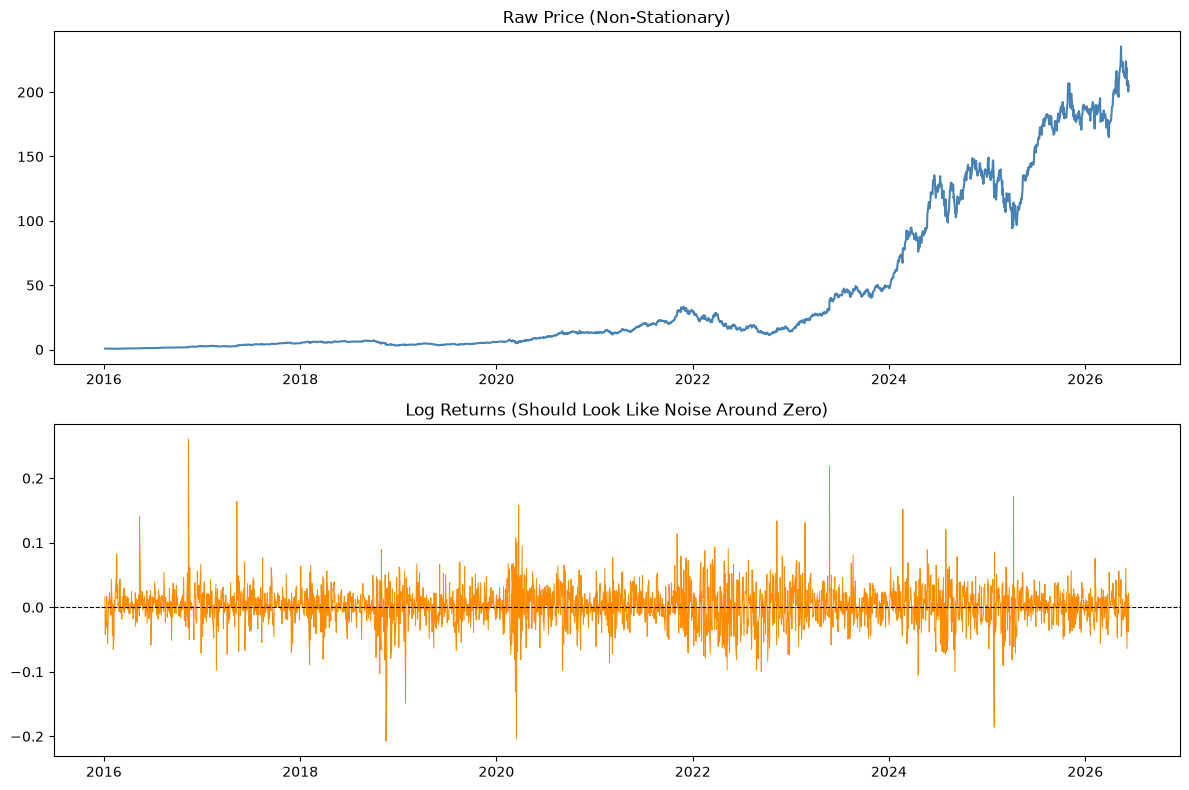

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(df.index, df["price_close"], color="steelblue")
axes[0].set_title("Raw Price (Non-Stationary)")

axes[1].plot(df.index, df["log_returns"], color="darkorange", linewidth=0.7)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Log Returns (Should Look Like Noise Around Zero)")

plt.tight_layout()
plt.show()

Visual Analysis:
- The occasional spikes out to +/- 0.2 are plausible one-day moves for NVDA. We do not attribute this to any anomalies or inaccuracies in our data processing. 
- The data is centered tightly around 0 wit no visible trend or drift across the 10-year span! 
- Volatility clustering is visible too. We expect tighter bands in the calm years (2016-2017) and wider swings on the known stress periods as learnt from the raw price graph. 

## B: Technical Indicators

Log returns capture *direction and magnitude*, but not market "state". E.g. is the stock currently overbought, or is momentum shifting? Technical indicators like RSI and MACD give the model that extra context.

We'll use the `pandas_ta` library to add these as new columns.

Note: `pandas_ta` (Pandas Technical Analysis) is a robust, lightweight Python library that extends Pandas DataFrames to calculate over 190 technical indicators and 60 candlestick patterns directly on financial time series data.

### What is Relative Strength Index (RSI)?

RSI is a momentum oscillator bounded between 0 and 100. It compares the average size of recent up-moves to recent down-moves over a lookback window (`N` days). Intuitively:
- RSI > 70 = stock has been rising sharply, often read as "overbought". Thus the stock may be due for a pullback and it conventionally signals a sell. 
- RSI < 30 = stock has been falling sharply, often read as "oversold". The inverse of RSI > 70, signalling a buy.

It's a state feature. It doesn't tell the model the price, just how stretched recent momentum is.

### What is Moving Average Convergence Divergence (MACD)?

[MACD](https://www.investopedia.com/terms/m/macd.asp) is a trend-following indicator built from the difference between a fast EMA (12-day) and a slow EMA (26-day). A signal line (9-day EMA of the MACD line) is then used to spot crossovers:

- MACD line crosses above signal = momentum turning bullish
- MACD line crosses below signal = momentum turning bearish

### Combining the effects of RSI and MACD

We hope these extra contexts can provide our model with more comprehensive "features" to learn and make better predictions, and reflect it clearly in any model we use, by having high test set accuracy. 

In [5]:
import pandas_ta as ta

df["rsi_14"] = ta.rsi(df["price_close"], length=14)
macd = ta.macd(df["price_close"], fast=12, slow=26, signal=9)
df = pd.concat([df, macd], axis=1)

df.tail()

,symbol,price_close,volume,log_returns,rsi_14,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9
time,,,,,,,,
2026-06-08 00:00:00+00:00,NVDA,208.639999,138372800,0.017113,46.873536,1.604963,-2.127536,3.732499
2026-06-09 00:00:00+00:00,NVDA,208.190002,180962500,-0.002159,46.548084,0.981222,-2.201022,3.182243
2026-06-10 00:00:00+00:00,NVDA,200.419998,161746600,-0.038036,41.225513,-0.138475,-2.656575,2.518100
2026-06-11 00:00:00+00:00,NVDA,204.869995,158643200,0.021960,45.097509,-0.659167,-2.541814,1.882646
2026-06-12 00:00:00+00:00,NVDA,205.190002,112001800,0.001561,45.376193,-1.034077,-2.333379,1.299301


Note: 
- `MACD_12_26_9` is the MACD line itself (12 days EMA − 26 days EMA)
- `MACDh_12_26_9` is the histogram (MACD line − signal line)
- `MACDs_12_26_9` is the signal line (EMA of the MACD line)

In [6]:
print("NaNs introduced by indicators:")
print(df[["rsi_14"] + list(macd.columns)].isna().sum())

# Drop rows where indicators haven't "warmed up" yet
df_clean = df.dropna(subset=["rsi_14"] + list(macd.columns)).copy()
print(f"\nRows before: {len(df)}, after dropping warm-up NaNs: {len(df_clean)}")

NaNs introduced by indicators:
rsi_14            1
MACD_12_26_9     25
MACDh_12_26_9    33
MACDs_12_26_9    33
dtype: int64

Rows before: 2625, after dropping warm-up NaNs: 2592


## C: Prevent Data Leakage

To prevent data leakage between training data set and test data set, it is important for us to set the partitioning clear. Any mathematical manipulations to the raw data from training data should not be influenced by the behaviour of test set. 

We want to prevent any quiet invalidation of every result downstream.

**Rules to follow:**
1. **Chronological split only.** No `train_test_split(shuffle=True)`. Use the first ~80% of rows (by time) for training, the last ~20% for testing.
2. **Fit scalers on the training set only.** Then use that *same* fitted scaler object to transform both train and test.

In [7]:
split_idx = int(len(df_clean) * 0.8)

train_df = df_clean.iloc[:split_idx].copy()
test_df = df_clean.iloc[split_idx:].copy()

print(f"Train: {train_df.index.min()} to {train_df.index.max()} ({len(train_df)} rows)")
print(f"Test:  {test_df.index.min()} to {test_df.index.max()} ({len(test_df)} rows)")

Train: 2016-02-23 00:00:00+00:00 to 2024-05-16 00:00:00+00:00 (2073 rows)
Test:  2024-05-17 00:00:00+00:00 to 2026-06-12 00:00:00+00:00 (519 rows)


In [9]:
from sklearn.preprocessing import MinMaxScaler

feature_cols = ["log_returns", "rsi_14"] + list(macd.columns)

scaler = MinMaxScaler()
scaler.fit(train_df[feature_cols])  # fit on TRAIN ONLY

train_scaled = scaler.transform(train_df[feature_cols])
test_scaled = scaler.transform(test_df[feature_cols])  # reuse same scaler, no re-fit

train_scaled_df = pd.DataFrame(train_scaled, columns=feature_cols, index=train_df.index)
test_scaled_df = pd.DataFrame(test_scaled, columns=feature_cols, index=test_df.index)

train_scaled_df.head()

,log_returns,rsi_14,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9
time,,,,,
2016-02-23 00:00:00+00:00,0.448682,0.539660,0.215366,0.606728,0.200208
2016-02-24 00:00:00+00:00,0.458078,0.553239,0.216013,0.606549,0.200980
2016-02-25 00:00:00+00:00,0.447962,0.557755,0.216523,0.606052,0.201710
2016-02-26 00:00:00+00:00,0.429173,0.538161,0.216855,0.605193,0.202367
2016-02-29 00:00:00+00:00,0.429366,0.518469,0.217045,0.604137,0.202935
